# SECOP II - Resultados variables e IRIC

En este notebook se realiza el análisis descriptivo y exploratorio para los datos de SECOP II - Master, y se crean las gráficas a usar en el artículo. Así mismo, se desarrolla 

# Entorno

In [ ]:
import sys
print(sys.executable)
print(sys.getdefaultencoding())

c:\Users\Home\anaconda3\envs\vigia\python.exe
utf-8


In [2]:
#Librerias
import os
import re
import datetime
import time
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns

pd.plotting.register_matplotlib_converters()
pd.set_option('display.max_columns', None, 'display.max_colwidth', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
#pd.options.display.max_colwidth = 100

In [3]:
os.getcwd()

'd:\\Documents\\vigia_article'

# Descripción variables iniciales

Se usan para poder crear estadísticas descriptivas y figuras que dependan del tiempo.

In [4]:
secopII_t = pd.read_csv('created_data\SECOPII_Master_t.csv')

In [5]:
secopII_t.shape

(87387, 61)

In [6]:
secopII_t['Modalidad de Contratacion'].value_counts(normalize=True)

Contratación directa                                          0.606
Contratación régimen especial                                 0.308
Mínima cuantía                                                0.028
Contratación Directa (con ofertas)                            0.015
Selección Abreviada de Menor Cuantía                          0.011
Selección abreviada subasta inversa                           0.011
Concurso de méritos abierto                                   0.007
Licitación pública                                            0.006
Contratación régimen especial (con ofertas)                   0.006
Licitación pública Obra Publica                               0.002
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes   0.000
Enajenación de bienes con subasta                             0.000
Name: Modalidad de Contratacion, dtype: float64

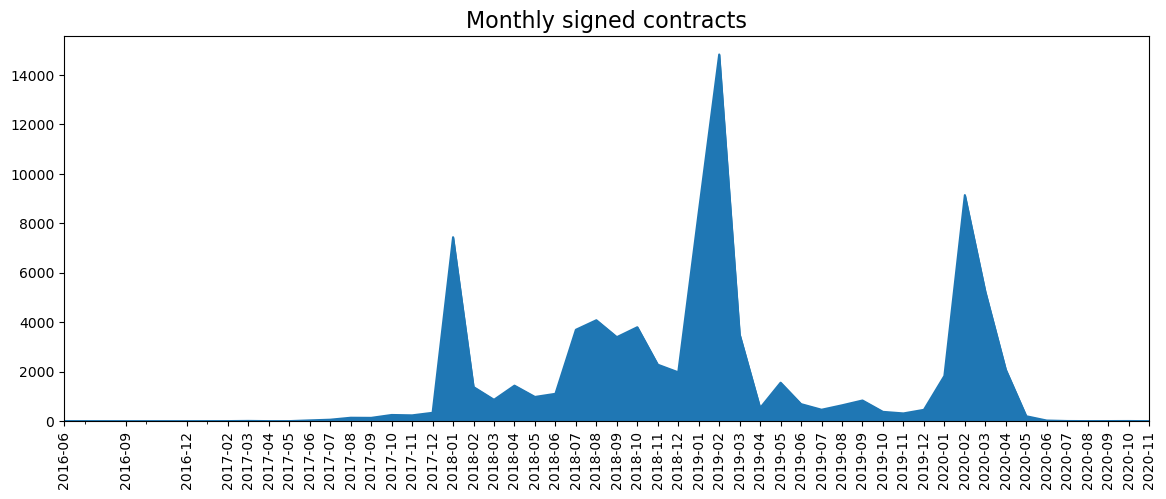

In [7]:
#Dar formato de fecha
secopII_t['Fecha de Firma'] = pd.to_datetime(secopII_t['Fecha de Firma'], format='%m/%d/%Y')
#Dar formato de periodicidad mensual
conteo_mensual_contratos = secopII_t['Fecha de Firma'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(14,5))
conteo_mensual_contratos.plot(kind='area')
plt.xticks(conteo_mensual_contratos.index, conteo_mensual_contratos.index, rotation=90)
plt.title('Monthly signed contracts', fontsize=16)
plt.show()

#Guardar
#plt.savefig('created_data/serie_contratos_firmados_mensual.png', bbox_inches = "tight")

In [8]:
(secopII_t['Fecha de Firma'] > '2020-01-01').value_counts()

False    68860
True     18527
Name: Fecha de Firma, dtype: int64

In [9]:
%%capture
modalities_data = secopII_t[['Modalidad de Contratacion', 'Fecha de Firma']].copy()

other_modalities = secopII_t['Modalidad de Contratacion'].value_counts().index[3:]
other_pos = secopII_t['Modalidad de Contratacion'].isin(other_modalities)

modalities_data.loc[other_pos, 'Modalidad de Contratacion'] = 'Otras'
modalities_data['mes_firma'] = secopII_t['Fecha de Firma'].dt.to_period('M')

modalities_plot_data = modalities_data.groupby(by=['Modalidad de Contratacion', 'mes_firma']).count().reset_index()
modalities_plot_data.rename(columns={'Fecha de Firma':'conteo'}, inplace=True)

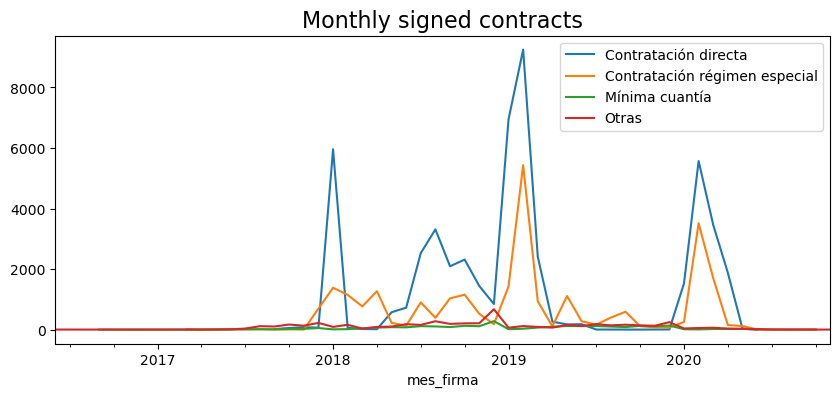

In [10]:
fig, ax = plt.subplots(figsize=(10,4))
for key, grp in modalities_plot_data.groupby(['Modalidad de Contratacion']):
    grp.plot(x='mes_firma', y='conteo', ax=ax, label=key)
    #ax.plot(grp['mes_firma'], grp['conteo'], label=key)

ax.legend()
plt.title('Monthly signed contracts', fontsize=16)
#plt.xticks(conteo_mensual_contratos.index, conteo_mensual_contratos.index, rotation=90)
plt.show()

In [11]:
modalities_data['anio_firma'] = modalities_data['Fecha de Firma'].dt.to_period('Y')

In [12]:
conteo_anual_contratos = pd.pivot_table(modalities_data,
                                        'mes_firma', 'anio_firma', 'Modalidad de Contratacion', 'count')
conteo_anual_contratos

Modalidad de Contratacion,Contratación directa,Contratación régimen especial,Mínima cuantía,Otras
anio_firma,,,,
2016,NaN,NaN,1.000,3.000
2017,215.000,75.000,129.000,782.000
2018,19878.000,9092.000,1108.000,2360.000
2019,19225.000,10703.000,1109.000,1603.000
2020,12464.000,5740.000,86.000,241.000


In [13]:
conteo_anual_contratos.columns

Index(['Contratación directa', 'Contratación régimen especial',
       'Mínima cuantía', 'Otras'],
      dtype='object', name='Modalidad de Contratacion')

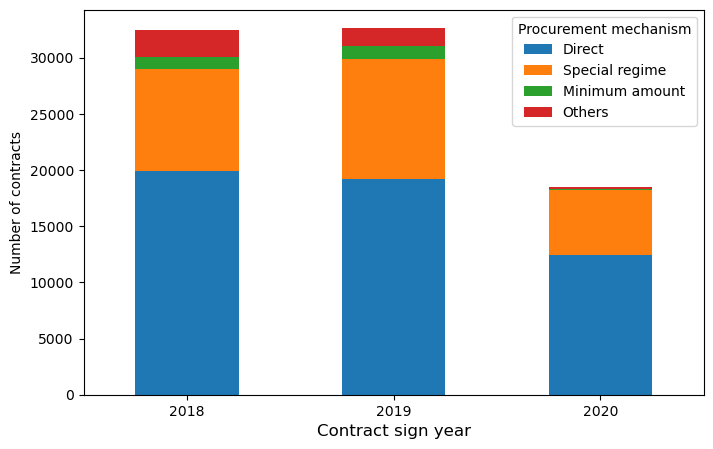

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
conteo_anual_contratos[conteo_anual_contratos.index > '2017'].plot.bar(stacked=True, ax=ax)
#ax.set_xticklabels(rotation=0)
ax.set_xlabel('Contract sign year', fontsize=12)
ax.set_ylabel('Number of contracts')
ax.legend(['Direct', 'Special regime', 'Minimum amount', 'Others'],
          loc='upper right', title='Procurement mechanism')
plt.xticks(rotation=0)
#ax.set_title('Number of contracts by modality across the years', fontsize=16) # Caption in doc
plt.savefig('created_data/figures/bar_contracts_year_modality.svg')
plt.savefig('created_data/figures/bar_contracts_year_modality.jpeg')

# Exploración - variables modelación

Para obtener los datos de la presente sección desde los anteriores se eliminaron variables que no presentaban variabilidad, se crearon variables nuevas y se hizo limpieza de las mismas. Además, se excluyeron de la muestra las observaciones con valor del contrato mayor al cuantil 0.995 que no sean del tipo "Obra", y las observaciones con valores del Saldo CDP superiores al cuantil 0.999.

In [39]:
secopII_master = pd.read_csv("created_data/SECOPII_Master_2.csv")
# Eliminar nulos de contratos sin proceso
secopII_master.dropna(inplace=True)

secopII_master['Codigo Segmento Categoria Principal'] = secopII_master['Codigo Segmento Categoria Principal'].astype('O')

In [40]:
secopII_master.shape

(82482, 47)

In [41]:
adiciones = secopII_master['Tuvo_adiciones'].value_counts()
adiciones

0    54188
1    28294
Name: Tuvo_adiciones, dtype: int64

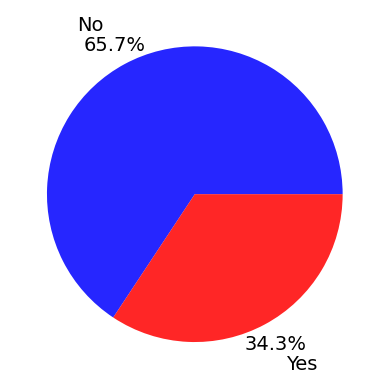

In [42]:
fig, ax = plt.subplots()
ax.pie(adiciones, labels=['No', 'Yes'], labeldistance=1.3, 
      pctdistance=1.15, autopct="%.1f%%", textprops={'fontsize': 14},
      colors=['b','r'], wedgeprops={'alpha':0.85})
#plt.title('Did the contract have additions?', fontsize=16)
plt.savefig('created_data/figures/pie_additions.svg')
plt.savefig('created_data/figures/pie_additions.jpeg')

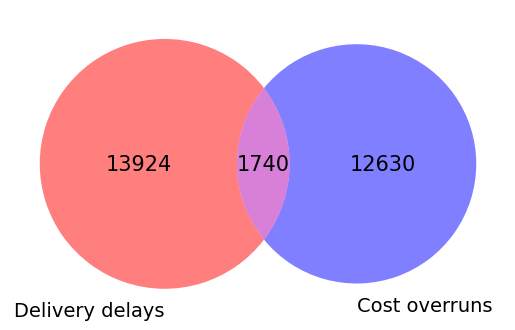

In [43]:
## Additions plots article
conteo_tipoadic = secopII_master.loc[secopII_master['Tuvo_adiciones']==1, 
                                     ['Tuvo_adiciones_valor', 'Tuvo_adiciones_tiempo']].value_counts().reset_index()
conteo_tipoadic.index = ['Delivery delays', 'Cost overruns', 'Additions']

#Gráfica ven
plt.figure()
v = venn2(subsets=conteo_tipoadic[0], set_labels=conteo_tipoadic.index,
          set_colors=('r', 'b'), alpha=0.5
         )
#plt.title('Distribution of contracts with additions', fontsize=16)

for text in v.set_labels:
    text.set_fontsize(14)
for text in v.subset_labels:
    text.set_fontsize(15)
    
plt.savefig('created_data/figures/venndiag_additions.svg')
plt.savefig('created_data/figures/venndiag_additions.jpeg')

In [44]:
other_modalities = secopII_master['Modalidad de Contratacion'].value_counts().index[3:]
other_pos = secopII_master['Modalidad de Contratacion'].isin(other_modalities)

modalidad = secopII_master['Modalidad de Contratacion'].copy()
modalidad[other_pos] = 'Otras'
modalidad_c = modalidad.value_counts()

In [45]:
modalidad_c.index

Index(['Contratación directa', 'Contratación régimen especial', 'Otras',
       'Mínima cuantía'],
      dtype='object')

Text(0.5, 1.1, 'Contracting modality')

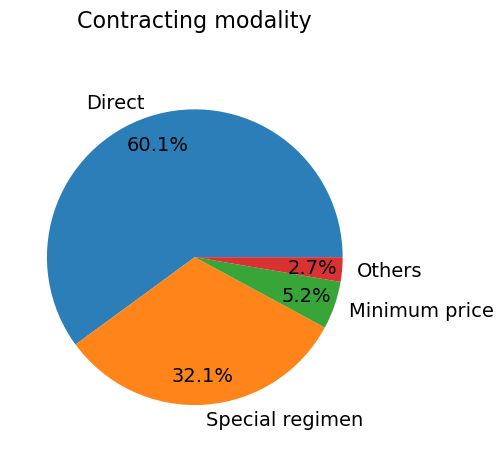

In [46]:
eng_labels = ['Direct', 'Special regimen', 'Minimum price', 'Others']
fig, ax = plt.subplots()
ax.pie(modalidad_c, labels=eng_labels, labeldistance=1.1, 
      pctdistance=0.8, autopct="%.1f%%", textprops={'fontsize': 14},
      wedgeprops={'alpha':0.95})
plt.title('Contracting modality', fontsize=16, y=1.1)

In [47]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [48]:
secopII_master.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 82482 entries, 0 to 87026
Data columns (total 47 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   ID Contrato                              82482 non-null  object 
 1   Nombre Entidad                           82482 non-null  object 
 2   Nit Entidad                              82482 non-null  int64  
 3   Sector                                   82482 non-null  object 
 4   Entidad Centralizada                     82482 non-null  object 
 5   Tipo de Contrato                         82482 non-null  object 
 6   Modalidad de Contratacion                82482 non-null  object 
 7   Justificacion Modalidad de Contratacion  82482 non-null  object 
 8   Fecha de Firma                           82482 non-null  object 
 9   TipoDocProveedor                         82482 non-null  object 
 10  Documento Proveedor                      82482

In [49]:
secopII_master['Sector'].value_counts(normalize=True)

Salud y Protección Social           0.434
Servicio Público                    0.173
Cultura                             0.141
Ambiente y Desarrollo Sostenible    0.059
Vivienda, Ciudad y Territorio       0.040
Transporte                          0.036
No aplica/No pertenece              0.024
Hacienda y Crédito Público          0.018
Educación Nacional                  0.017
defensa                             0.017
Inclusión Social y Reconciliación   0.014
Planeación                          0.014
Industria                           0.010
Ley de Justicia                     0.001
Name: Sector, dtype: float64

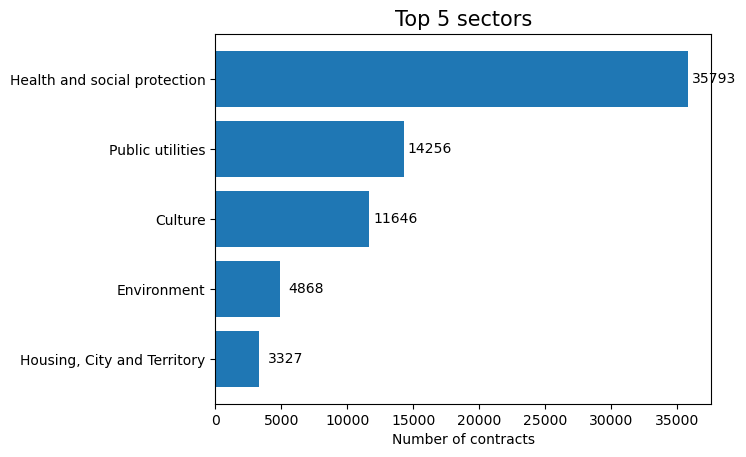

In [50]:
top5_sectores = secopII_master['Sector'].value_counts()[:5]
eng_labels = ['Health and social protection', 'Public utilities', 'Culture',
              'Environment', 'Housing, City and Territory']
plt.figure()
ax = plt.barh(eng_labels[::-1], top5_sectores[::-1])
for p in ax.patches:
    width = p.get_width()
    plt.text(p.get_width()+2000, p.get_y()+0.5*p.get_height(),
             '{:1.0f}'.format(width),
             ha='center', va='center')
plt.xlabel('Number of contracts')
plt.title( 'Top 5 sectors', fontsize=15)


plt.show()

In [51]:
secopII_master['Justificacion Modalidad de Contratacion'].value_counts()

ServiciosProfesionales                                                                        46974
Regla aplicable                                                                               24029
Presupuesto inferior al 10% de la menor cuantía                                                3081
Decreto 092 de 2017                                                                            2820
ContratosConveniosInteradministrativosValorCero                                                2039
Ley 1150 de 2007                                                                                974
Suministro de bienes y servicios de características técnicas uniformes y común utilización      779
Ejecución de trabajos artísticos                                                                512
No existe pluralidad de oferentes en el mercado                                                 325
Arrendamiento de inmuebles                                                                      214


In [52]:
secopII_master['Grupo categoria principal'].value_counts()

Servicios administrativos               64967
Servicios(No Admin)                     15044
Productos manufacturados                 1740
Componentes y suministros de equipos      343
Materias primas                           210
Equipo industrial                         178
Name: Grupo categoria principal, dtype: int64

In [53]:
idx_ps = secopII_master['Tipo de Contrato'] == 'Prestación de servicios'
secopII_master.loc[~idx_ps, ['Dias Inicio-Firma Contrato', 'Dias Inicio-Firma Ejecucion']]\
    .describe(percentiles=[0.25, 0.4, 0.5, 0.75]).T

,count,mean,std,min,25%,40%,50%,75%,max
Dias Inicio-Firma Contrato,9348.000,-9.048,32.458,-904.000,-5.000,-1.000,0.000,2.000,191.000
Dias Inicio-Firma Ejecucion,9348.000,6.138,55.065,-904.000,-2.000,0.000,1.000,5.000,496.000


In [54]:
secopII_master.columns

Index(['ID Contrato', 'Nombre Entidad', 'Nit Entidad', 'Sector',
       'Entidad Centralizada', 'Tipo de Contrato', 'Modalidad de Contratacion',
       'Justificacion Modalidad de Contratacion', 'Fecha de Firma',
       'TipoDocProveedor', 'Documento Proveedor', 'Es Grupo', 'Es Pyme',
       'Habilita Pago Adelantado', 'Liquidación', 'Obligación Ambiental',
       'Valor del Contrato', 'Saldo CDP', 'EsPostConflicto', 'Destino Gasto',
       'Proveedores Invitados', 'Proveedores con Invitacion Directa',
       'Conteo de Respuestas a Ofertas', 'Proveedores Unicos con Respuestas',
       'Fecha de Publicacion del Proceso', 'Fecha de Ultima Publicación',
       'Numero_de_procesos_reportados', 'Codigo Segmento Categoria Principal',
       'Numero multas SIC proveedor', 'Valor acumulado multas SIC proveedor',
       'Tipo Empresa Proveedor', 'Dias Inicio-Firma Contrato',
       'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
       'Dias Fin-Inicio Ejecucion', 'Dias Proveedor In

Gráficas por tipo de contrato.

El Decreto 092 de 2017 reglamenta la contratación con entidades privadas sin ánimo de lucro.

In [55]:
secopII_master['Tipo de Contrato'].value_counts()

Prestación de servicios       73134
Otro                           2993
Decreto 092 de 2017            2820
Compraventa                    1169
Suministros                    1016
Interventoría                   388
Obra                            376
Consultoría                     240
Arrendamiento de inmuebles      214
Seguros                         132
Name: Tipo de Contrato, dtype: int64

In [56]:
# 'Tipo de Contrato', 'Dias Fin-Inicio Contrato'
diff_otro_pos = secopII_master['Tipo de Contrato'] != 'Otro'
other_types = secopII_master['Tipo de Contrato'][diff_otro_pos].value_counts().index[4:]
other_types = list(other_types) + ['Otro']
other_pos = secopII_master['Tipo de Contrato'].isin(other_types)

tipos = secopII_master['Tipo de Contrato'].copy()
tipos[other_pos] = 'Otros'
tipos_c = tipos.value_counts()

Text(0.5, 1.0, 'Contracting type')

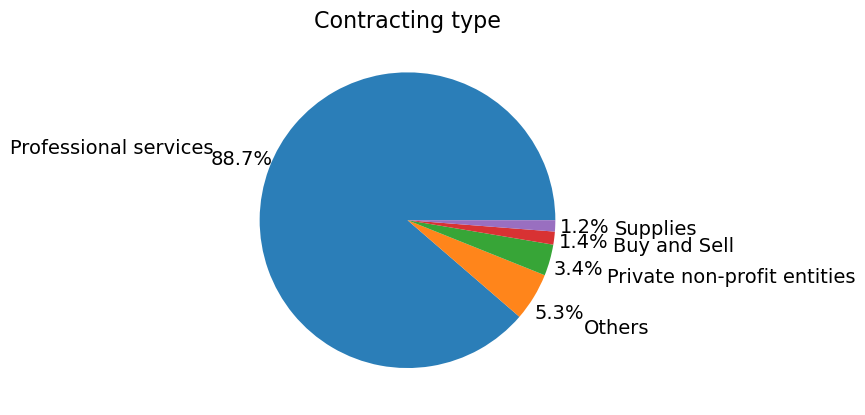

In [57]:
eng_labels = ['Professional services', 'Others', 'Private non-profit entities',
              'Buy and Sell', 'Supplies']
fig, ax = plt.subplots()
ax.pie(tipos_c, labels=eng_labels, labeldistance=1.4, 
      pctdistance=1.2, autopct="%.1f%%", textprops={'fontsize': 14},
      wedgeprops={'alpha':0.95})
plt.title('Contracting type', fontsize=16)


In [58]:
tipos_c

Prestación de servicios    73134
Otros                       4343
Decreto 092 de 2017         2820
Compraventa                 1169
Suministros                 1016
Name: Tipo de Contrato, dtype: int64

In [59]:
eng_labels = ['Professional services', 'Others', 'Private non-profit entities',
              'Buy and Sell', 'Supplies']
esp_labels = ['Prestación de servicios', 'Otros', 'Decreto 092 de 2017', 'Compraventa',
              'Suministros']
tipos = tipos.replace(dict(zip(esp_labels, eng_labels)))

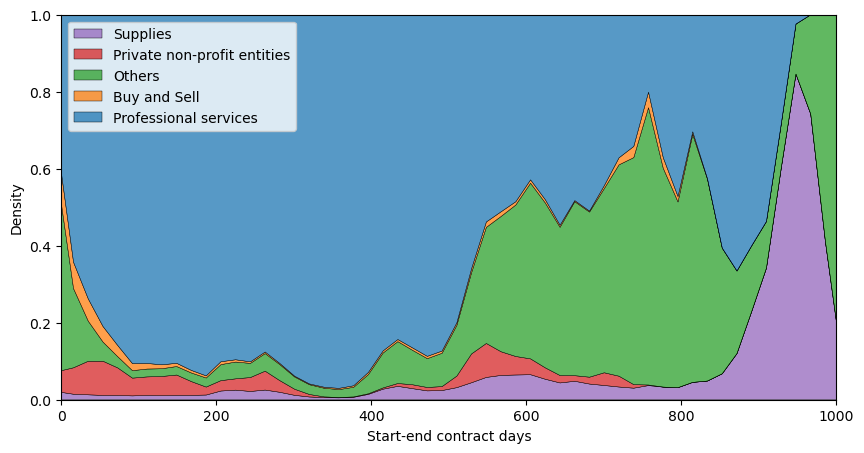

In [60]:
data_copy = secopII_master[['Dias Fin-Inicio Contrato', 'Tipo de Contrato']].copy()
data_copy['Contract type'] = tipos

plt.figure(figsize=(10,5))
sns.kdeplot(data=data_copy, x='Dias Fin-Inicio Contrato', hue='Contract type', multiple="fill",
           linewidth=0.3)
plt.xlim([0,1000])
plt.xlabel('Start-end contract days')
plt.legend(['Supplies', 'Private non-profit entities', 'Others',
              'Buy and Sell', 'Professional services'],loc='upper left')

plt.savefig('created_data/figures/kde_time_by_Ctype.svg')
plt.savefig('created_data/figures/kde_time_by_Ctype.jpeg')

# Correlaciones variables explicativas

In [65]:
add_vars = ['Tuvo_adiciones_valor', 'Tuvo_adiciones_tiempo', 'Tuvo_adiciones']
corr_matrix = secopII_master.corr()[add_vars].drop(index=add_vars)
print(corr_matrix.index)
corr_matrix.drop(index=['Nit Entidad', 'Tiene_variables_portafolio', 
                        'Proveedores Unicos con Respuestas'], inplace=True)

# Vars names to english
corr_matrix.columns = ['Cost overruns', 'Delivery delays', 'Any']
eng_expv_names = ['Value', 'Budget balance', 'Number of invited suppliers',
                 'Number of direct invited suppliers', 'Number of answers',
                 'Number of processes', 'Number of SIC sanctions',
                 'Value of SIC sanctions', 'Sign-start contract days',
                 'Start-end contract days', 'Sign-start execution days',
                 'Start-end execution days', 'Days supplier registered',
                 'Advance payment percentage', 'Balance/Value',
                 'Adevertisement period']
corr_matrix.index = eng_expv_names

Index(['Nit Entidad', 'Valor del Contrato', 'Saldo CDP',
       'Proveedores Invitados', 'Proveedores con Invitacion Directa',
       'Conteo de Respuestas a Ofertas', 'Proveedores Unicos con Respuestas',
       'Numero_de_procesos_reportados', 'Numero multas SIC proveedor',
       'Valor acumulado multas SIC proveedor', 'Dias Inicio-Firma Contrato',
       'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
       'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito',
       'Proporcion pagada adelantado', 'Saldo CDP respecto Valor',
       'Tiene_variables_portafolio', 'Dias Proceso Contratacion Abierto'],
      dtype='object')


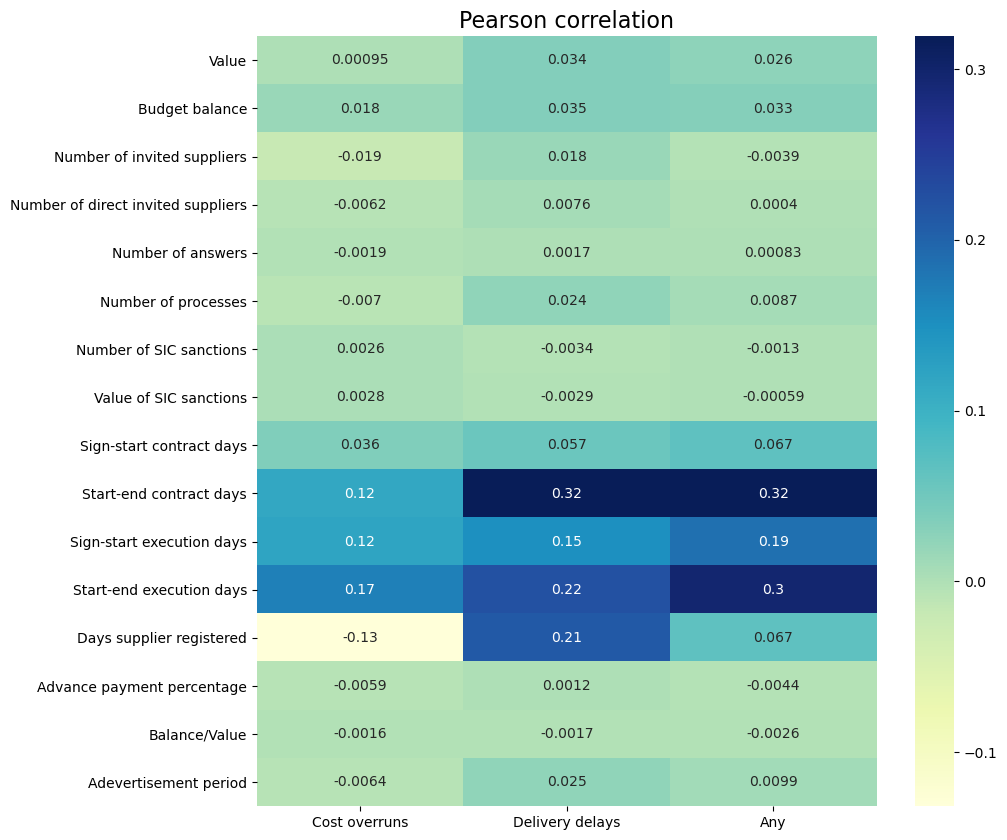

In [66]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, 
            annot=True, cmap='YlGnBu')
#plt.title('Pearson correlation between numerical explanatory variables and targets', fontsize=16)
plt.title('Pearson correlation', fontsize=16)
plt.savefig('created_data/figures/heatmap_pearsoncorr.svg', bbox_inches="tight")
plt.savefig('created_data/figures/heatmap_pearsoncorr.jpeg', bbox_inches="tight")
plt.show()

del corr_matrix

In [67]:
import pycorrcat.pycorrcat as corrcat

expl_cat = ['Sector', 'Entidad Centralizada',
           'Tipo de Contrato', 'Modalidad de Contratacion',
           'Justificacion Modalidad de Contratacion', 'TipoDocProveedor',
           'Es Grupo', 'Es Pyme', 'Habilita Pago Adelantado', 'Liquidación',
           'Obligación Ambiental', 'EsPostConflicto', 'Destino Gasto',
           'Codigo Segmento Categoria Principal', 'Tipo Empresa Proveedor',
           'Mes Firma Contrato', 'Grupo categoria principal',
           'Tipo Empresa Proveedor Resumido', 'Mes de Publicacion del Proceso'
           ]
eng_expl_cat = ['Sector', 'Centralized entity', 'Contract type',
                'Procurement mechanism', 'Procurement mechanism justification',
                'Supplier ID type', 'Is group', 'Is pyme', 'Allow pay in advance',
                'Sold out', 'Environmental obligation', 'Post-conflict',
                'Expenditure purpose', 'Product segment to contract',
                'Company type', 'Month of sign', 'Product group to contract',
                'Company type aggregation', 'Month of publication'
               ]

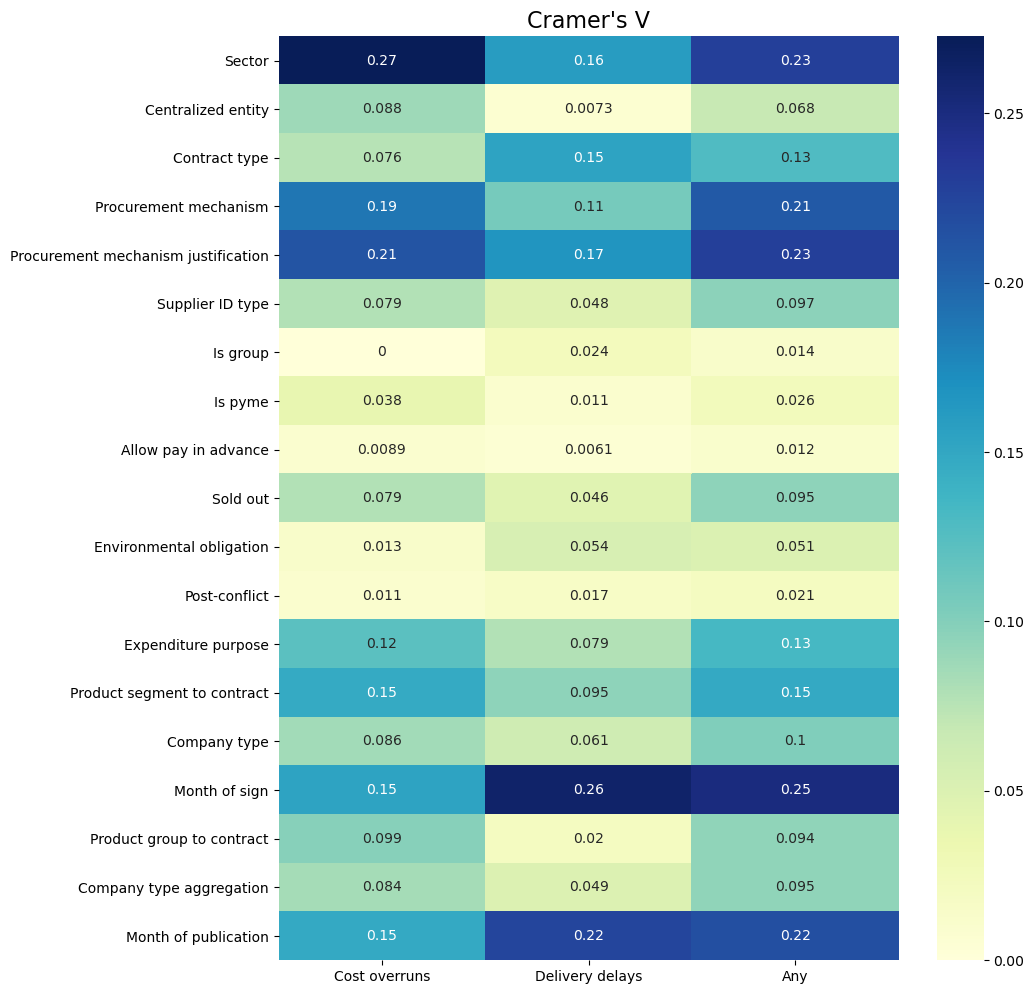

In [68]:
#Para variables categóricas usando la V de cramer
add_vars = ['Tuvo_adiciones_valor', 'Tuvo_adiciones_tiempo', 'Tuvo_adiciones']
catcorrM = corrcat.corr_matrix(secopII_master, 
                               columns=expl_cat+add_vars).drop(index=add_vars)
catcorrM = catcorrM[add_vars] 
# Vars names to english
catcorrM.columns = ['Cost overruns', 'Delivery delays', 'Any']
catcorrM.index = eng_expl_cat

# Plot
plt.figure(figsize=(10,12))
sns.heatmap(catcorrM[['Cost overruns', 'Delivery delays', 'Any']],
           annot=True, cmap='YlGnBu')
# plt.title('V de Cramer entre variables explicativas categóricas y objetivo', fontsize=16)
plt.title('Cramer\'s V', fontsize=16)
plt.savefig('created_data/figures/heatmap_cramersV.svg', bbox_inches="tight")
plt.savefig('created_data/figures/heatmap_cramersV.jpeg', bbox_inches="tight")
plt.show()

del catcorrM

# IRIC

## Construir datos a nivel de proveedor

In [214]:
secopII_t = pd.read_csv("created_data/SECOPII_Master_2.csv")

Aquí no se eliminan los nulos de proceso de contratación dado que la ausencia de estos datos indica una irregularidad contemplada en el IRIC.

In [215]:
secopII_t.shape

(87027, 47)

In [216]:
secopII_t['Fecha de Firma'] = pd.to_datetime(secopII_t['Fecha de Firma'])
secopII_t['Fecha de Firma'].describe(datetime_is_numeric=True)

count                            87027
mean     2019-02-05 15:27:13.272432896
min                2016-04-12 00:00:00
25%                2018-08-16 00:00:00
50%                2019-01-31 00:00:00
75%                2019-07-11 00:00:00
max                2020-11-13 00:00:00
Name: Fecha de Firma, dtype: object

Usar contratos firmados antes de 2020-01-01 para información de proveedor.

In [217]:
(secopII_t['Fecha de Firma'] > '2020-01-01').value_counts()

False    68235
True     18792
Name: Fecha de Firma, dtype: int64

In [218]:
secopII_t = secopII_t[secopII_t['Fecha de Firma'] < '2020-01-01']

In [219]:
secopII_t['Fecha de Firma'].describe(datetime_is_numeric=True)

count                            68231
mean     2018-10-21 19:10:40.477202688
min                2016-04-12 00:00:00
25%                2018-07-16 00:00:00
50%                2018-12-19 00:00:00
75%                2019-02-08 00:00:00
max                2019-12-31 00:00:00
Name: Fecha de Firma, dtype: object

In [220]:
vars_AP = ['Documento Proveedor', 'Tuvo_adiciones_valor', 'Tuvo_adiciones_tiempo']
vars_prov = ['proveedor_adiciones_valor', 'proveedor_adiciones_tiempo']

secopII_t[vars_prov] = secopII_t[vars_AP].groupby('Documento Proveedor').transform('sum').apply(lambda x: 1*(x!=0) )

# Base a nivel de proveedores
proveedores_adiciones = secopII_t[vars_AP].groupby('Documento Proveedor').sum().reset_index()

In [221]:
proveedores_adiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41784 entries, 0 to 41783
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Documento Proveedor    41784 non-null  object
 1   Tuvo_adiciones_valor   41784 non-null  int64 
 2   Tuvo_adiciones_tiempo  41784 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 979.4+ KB


In [222]:
secopII_t.rename(columns={'Documento Proveedor':'documento_proveedor'}, inplace=True)
proveedores_adiciones.rename(columns={'Documento Proveedor':'documento_proveedor'}, inplace=True)

In [223]:
secopII_t[['Nit Entidad', 'documento_proveedor']].value_counts()

Nit Entidad  documento_proveedor
900413030    860025674              431
899999061    NoDefinido             251
900413030    830029703              207
             860063869              181
             900719123              159
                                   ... 
900140515    52377953                 1
             52258812                 1
             52223650                 1
             51987055                 1
900126860    8300108934               1
Length: 44346, dtype: int64

In [224]:
# Historial del ganador: nÃºmero de contratos adjudicados.
proveedores_historial = secopII_t['documento_proveedor'].value_counts().reset_index()
proveedores_historial = proveedores_historial.rename(columns={'index':'documento_proveedor',
                                                            'documento_proveedor': 'numero_procesos'})

# Empresa multiproposito: Segmentos principales que ha servido.
# Base a nivel de proveedores
vars_cp = ['documento_proveedor','Codigo Segmento Categoria Principal']
proveedores_segmentos = secopII_t[vars_cp].groupby('documento_proveedor')['Codigo Segmento Categoria Principal'].apply(set).reset_index()

# Diversidad de entidades: Entidades con las que ha ganado contratos
vars_de = ['documento_proveedor','Nit Entidad']
proveedores_entidades = secopII_t.groupby('documento_proveedor')['Nit Entidad'].apply(set).reset_index()

In [225]:
idx_ps = (secopII_t['Tipo de Contrato'] == 'Prestación de servicios')
secopII_t.loc[idx_ps, 'TipoDocProveedor'].value_counts(1)


Cédula de Ciudadanía   0.921
NIT                    0.076
No Definido            0.001
Otro                   0.001
Name: TipoDocProveedor, dtype: float64

In [226]:
proveedor_tipodoc = secopII_t[['documento_proveedor', 'TipoDocProveedor']].groupby('documento_proveedor').first()
proveedor_tipodoc = proveedor_tipodoc.reset_index().rename(columns={'index':'documento_proveedor',
                                                            'TipoDocProveedor': 'tipo_documento'})

Unir datos

In [227]:
proveedores = proveedores_adiciones.merge(proveedores_historial,
                                        on='documento_proveedor',
                                        how='outer',
                                        validate='1:1'
                                        )
proveedores = proveedores.merge(proveedores_segmentos,
                                on='documento_proveedor',
                                how='outer',
                                validate='1:1'
                            )
proveedores = proveedores.merge(proveedores_entidades,
                                on='documento_proveedor',
                                how='outer',
                                validate='1:1'
                            )
proveedores = proveedores.merge(proveedor_tipodoc,
                                on='documento_proveedor',
                                how='outer',
                                validate='1:1'
                            )
# Modificar nombres
proveedores.rename(columns={'Nit Entidad':'codigos_entidades',
                            'Codigo Segmento Categoria Principal': 'segmentos_de_categoria_principal',
                            'Tuvo_adiciones_valor': 'numero_adiciones_valor',
                            'Tuvo_adiciones_tiempo': 'numero_adiciones_tiempo'
                        },inplace=True)

# NÃºmero segmentos
proveedores['segmentos_de_categoria_principal'] = proveedores['segmentos_de_categoria_principal'].apply(len)

#NÃºmero entidades
proveedores['codigos_entidades'] = proveedores['codigos_entidades'].apply(len)

In [228]:
proveedores.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41784 entries, 0 to 41783
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   documento_proveedor               41784 non-null  object
 1   numero_adiciones_valor            41784 non-null  int64 
 2   numero_adiciones_tiempo           41784 non-null  int64 
 3   numero_procesos                   41784 non-null  int64 
 4   segmentos_de_categoria_principal  41784 non-null  int64 
 5   codigos_entidades                 41784 non-null  int64 
 6   tipo_documento                    41784 non-null  object
dtypes: int64(5), object(2)
memory usage: 2.6+ MB


In [229]:
proveedores['numero_procesos'].describe(percentiles=[.5, .75, .9, .95, .975])

count   41784.000
mean        1.633
std         3.781
min         1.000
50%         1.000
75%         2.000
90%         3.000
95%         3.000
97.5%       4.000
max       475.000
Name: numero_procesos, dtype: float64

In [230]:
proveedores.groupby('tipo_documento')['numero_procesos'].describe(percentiles=[.5, .75, .9, .95, .975])

,count,mean,std,min,50%,75%,90%,95%,97.5%,max
tipo_documento,,,,,,,,,,
Cédula de Ciudadanía,37413.000,1.535,0.779,1.000,1.000,2.000,3.000,3.000,3.000,15.000
NIT,4258.000,2.506,11.580,1.000,1.000,2.000,4.000,6.000,9.000,475.000
No Definido,46.000,1.109,0.315,1.000,1.000,1.000,1.500,2.000,2.000,2.000
Otro,67.000,1.328,0.960,1.000,1.000,1.000,2.000,2.000,3.000,8.000


Con la revisión de las distribuciones se define que un proveedor con frecuente historial es irregular si el número de procesos es mayor a 3 para proveedores con cédula de ciudadanía, asociado a contratos de prestación de servicios; o mayor a 6 para los demás contratos.(P95)

In [231]:
proveedores.isna().sum()

documento_proveedor                 0
numero_adiciones_valor              0
numero_adiciones_tiempo             0
numero_procesos                     0
segmentos_de_categoria_principal    0
codigos_entidades                   0
tipo_documento                      0
dtype: int64

## Preparación variables

In [232]:
secop2_CE_api = pd.read_csv("created_data/SECOPII_Master_2.csv")

In [233]:
secop2_CE_api['Fecha de Firma'] = pd.to_datetime(secop2_CE_api['Fecha de Firma'])

In [234]:
secop2_CE_api['Fecha de Firma'].describe(datetime_is_numeric=True)

count                            87027
mean     2019-02-05 15:27:13.272432896
min                2016-04-12 00:00:00
25%                2018-08-16 00:00:00
50%                2019-01-31 00:00:00
75%                2019-07-11 00:00:00
max                2020-11-13 00:00:00
Name: Fecha de Firma, dtype: object

In [235]:
old_names = ['ID Contrato', 'Tipo de Contrato', 'Sector', 'Valor del Contrato', 'Fecha de Firma',
    'Justificacion Modalidad de Contratacion', 'Documento Proveedor',
    'Modalidad de Contratacion', 'TipoDocProveedor', 'Nombre Entidad', 'Proveedores Unicos con Respuestas',
    'Fecha de Publicacion del Proceso', 'Fecha de Ultima Publicación', 'Tiene_variables_portafolio']

new_names = ['id_contrato', 'tipo_de_contrato', 'sector', 'valor_del_contrato', 'fecha_de_firma',
    'justificacion_modalidad_de', 'documento_proveedor',
    'modalidad_de_contratacion', 'tipodocproveedor', 'nombre_entidad', 'proveedores_unicos_con',
    'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'tiene_variables_portafolio']
rename_dict = dict(zip(old_names, new_names))

# New data
secop2_CE_api.rename(columns=rename_dict, inplace=True)

In [236]:
## Formatos
# Fechas
var_fechas = ['fecha_de_firma',
            'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci'
            ]
secop2_CE_api[var_fechas] = secop2_CE_api[var_fechas].apply(pd.to_datetime)

# Numéricas
secop2_CE_api['valor_del_contrato'] = secop2_CE_api['valor_del_contrato'].astype('int64')

# Distancias entre fechas
secop2_CE_api['Dias Proceso Contratacion Abierto'] = (secop2_CE_api['fecha_de_ultima_publicaci'] - \
                                                    secop2_CE_api['fecha_de_publicacion_del']).dt.days
secop2_CE_api['Periodo de Decision'] = (secop2_CE_api['fecha_de_firma'] - \
                                        secop2_CE_api['fecha_de_ultima_publicaci']).dt.days

In [237]:
# Para días proveedor inscrito
# Para días proceso de contratación abierto
# Dar valor de 0 a negativos, -1, y vacios con 0
secop2_CE_api.loc[secop2_CE_api['Dias Proceso Contratacion Abierto'] < 0, 'Dias Proceso Contratacion Abierto'] = 0
secop2_CE_api['Dias Proceso Contratacion Abierto'].fillna(0, inplace=True)
secop2_CE_api['Dias Proceso Contratacion Abierto'] = secop2_CE_api['Dias Proceso Contratacion Abierto'].astype(int)

# Para días del periodo de decisión
# Dar valor de 0 a negativos, -1. Y vacios con 0
secop2_CE_api.loc[secop2_CE_api['Periodo de Decision'] < 0, 'Periodo de Decision'] = 0
secop2_CE_api['Periodo de Decision'].fillna(0, inplace=True)
secop2_CE_api['Periodo de Decision'] = secop2_CE_api['Periodo de Decision'].astype(int)

### Distribuciones de periodos y log valor

**Prestación de servicios**

In [238]:
idx_ps = (secop2_CE_api['tipo_de_contrato'] == 'Prestación de servicios')
(secop2_CE_api['tipo_de_contrato'] == 'Prestación de servicios').value_counts()

True     77058
False     9969
Name: tipo_de_contrato, dtype: int64

In [239]:
secop2_CE_api.loc[idx_ps, 'Dias Proceso Contratacion Abierto'].describe(percentiles=[0.1, 0.5, 0.75, 0.95, .975, .99,]).to_frame().T

,count,mean,std,min,10%,50%,75%,95%,97.5%,99%,max
Dias Proceso Contratacion Abierto,77058.000,0.249,2.431,0.000,0.000,0.000,0.000,0.000,0.000,14.000,188.000


In [240]:
secop2_CE_api.loc[idx_ps, 'Periodo de Decision'].describe(percentiles=[0.1, 0.5, 0.75, 0.95, .975, .99,]).to_frame().T 

,count,mean,std,min,10%,50%,75%,95%,97.5%,99%,max
Periodo de Decision,77058.000,9.966,26.143,0.000,0.000,2.000,7.000,43.000,97.000,125.000,785.000


In [241]:
np.log(secop2_CE_api.loc[idx_ps, 'valor_del_contrato']+1).describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T

,count,mean,std,min,25%,50%,75%,max
valor_del_contrato,77058.000,16.787,1.316,0.000,16.158,16.841,17.511,21.867


Para los contratos de prestación de servicios:
- Un periodo en que el contrato está abierto a recibir ofertas es **extremo** si es 0 o mayor a 14 días (p99).
- Un periodo de decisión es extremo si es 0 o mayor a 43 días (p95)
- El p75 para la ponderación del IRICP es 17.51

**No prestación de servicios**

In [242]:
idx_nps = (secop2_CE_api['tipo_de_contrato'] != 'Prestación de servicios')

In [243]:
secop2_CE_api.loc[idx_nps, 'Dias Proceso Contratacion Abierto'].describe(percentiles=[0.1, 0.5, 0.75, 0.95, .975, .99,]).to_frame().T

,count,mean,std,min,10%,50%,75%,95%,97.5%,99%,max
Dias Proceso Contratacion Abierto,9969.000,2.978,8.824,0.000,0.000,0.000,0.000,19.000,22.000,31.000,300.000


In [244]:
secop2_CE_api.loc[idx_nps, 'Periodo de Decision'].describe(percentiles=[0.1, 0.5, 0.75, 0.95, .975, .99]).to_frame().T 

,count,mean,std,min,10%,50%,75%,95%,97.5%,99%,max
Periodo de Decision,9969.000,19.292,33.533,0.000,0.000,8.000,31.000,55.000,71.000,125.000,988.000


In [245]:
np.log(secop2_CE_api.loc[idx_nps, 'valor_del_contrato']+1).describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T

,count,mean,std,min,25%,50%,75%,max
valor_del_contrato,9969.000,13.812,7.272,0.000,14.905,16.475,18.107,25.176


Para los contratos de tipo **diferente a** prestación de servicios:
- Un periodo en que el contrato está abierto a recibir ofertas es **extremo** si es 0 o mayor a 31 días (p99).
- Un periodo de decisión es extremo si es 0 o mayor a 55 días (p95)
- El p75 para la ponderación del IRICP es 18.11

In [246]:
secop2_CE_api['proveedores_unicos_con'].describe()

count   82482.000
mean        0.464
std         2.945
min         0.000
25%         0.000
50%         0.000
75%         0.000
max       165.000
Name: proveedores_unicos_con, dtype: float64

In [247]:
secop2_CE_api['proveedores_unicos_con'].value_counts().sort_index().head()

0.000    76080
1.000     1881
2.000      882
3.000      663
4.000      525
Name: proveedores_unicos_con, dtype: int64

## Calcular índice

Usar contratos firmados desde de 2020-01-01 para calcular indice a contratos con registro previo de proveedor.

In [248]:
secop2_CE_api = secop2_CE_api[secop2_CE_api['fecha_de_firma'] >= '2020-01-01'].copy()

In [249]:
(secop2_CE_api['tipo_de_contrato'] == 'Prestación de servicios').value_counts()

True     16681
False     2115
Name: tipo_de_contrato, dtype: int64

In [250]:
p_dum = proveedores.copy()
#del proveedores

Calculo de variables indicadoras y agregación de índice

In [251]:
# Proveedor con adiciones en valor
p_dum['adicion_valor_proveedor'] = p_dum['numero_adiciones_valor'].apply(lambda x: 1 * (x != 0))
# Proveedor con adiciones en tiempo
p_dum['adicion_tiempo_proveedor'] = p_dum['numero_adiciones_tiempo'].apply(lambda x: 1 * (x != 0))
# Proveedor recurrente
p_dum['proveedor_recurrente'] = p_dum['numero_procesos'].apply(lambda x: 1 * (x >= 5))
# Proveedor multiproposito
p_dum['proveedor_multiproposito'] = p_dum['segmentos_de_categoria_principal'].apply(lambda x: 1 * (x > 1))

# Proveedor recurrente
def get_proveedor_recurrente(row):
    if row['tipo_documento'] == 'Cédula de Ciudadanía':
        return (row['numero_procesos'] > 3) * 1
    else:
        return (row['numero_procesos'] > 6) * 1
p_dum['proveedor_recurrente'] = p_dum.apply(get_proveedor_recurrente, axis=1)

# Proveedor multientidad
#p_dum['proveedor_multientidad'] = p_dum['codigos_entidades'].apply(lambda x: 1 * (x > 1))

# Agregar a contratos electrónicos
secop2_CE_api = secop2_CE_api.merge(p_dum, how='left',
                                    on='documento_proveedor',
                                    validate='m:1'
                                    )

## Contratación directa
secop2_CE_api['contratacion_directa'] = secop2_CE_api['modalidad_de_contratacion'].apply(
    (lambda x: 1 if ((x == 'Contratación directa') | (x == 'Contratación Directa (con ofertas)')) else 0))

## Contratación por régimen especial
secop2_CE_api['contratacion_regimen_especial'] = secop2_CE_api['modalidad_de_contratacion'].apply(
    (lambda x: 1 if (
                (x == 'Contratación régimen especial') | (x == 'Contratación régimen especial (con ofertas)')) else 0))

## Ausencia de proceso de contratación
secop2_CE_api['ausencia_proceso_contratacion'] = 1 - secop2_CE_api['tiene_variables_portafolio']

## Duración extrema del proceso de contratación
# Los umbrales escogidos con el percentil 99 definido anteriormente
def get_duracion_extrema_proceso(row):
    if row['tipo_de_contrato'] == 'Prestación de servicios':
        return ((row['Dias Proceso Contratacion Abierto'] == 0) | (row['Dias Proceso Contratacion Abierto'] > 14)) * 1
    else:
        return ((row['Dias Proceso Contratacion Abierto'] == 0) | (row['Dias Proceso Contratacion Abierto'] > 31)) * 1
secop2_CE_api['duracion_extrema_proceso'] = secop2_CE_api.apply(get_duracion_extrema_proceso, axis=1)

## Periodo de decisión extremo
def get_periodo_decision_extremo(row):
    if row['tipo_de_contrato'] == 'Prestación de servicios':
        return ((row['Periodo de Decision'] == 0) | (row['Periodo de Decision'] > 43)) * 1
    else:
        return ((row['Periodo de Decision'] == 0) | (row['Periodo de Decision'] > 55)) * 1
secop2_CE_api['periodo_decision_extremo'] = secop2_CE_api.apply(get_periodo_decision_extremo, axis=1)

## Proponente único
secop2_CE_api['proponente_unico'] = 1 * (secop2_CE_api['proveedores_unicos_con'] <= 1)


## Errores o ausencia de datos.
# Esta se basa en 3 características clave: identificación del proveedor, registro del valor
#  y justificación de la modalidad de contratación.

# Errores en identificación del proveedor.
def error_doc(row):
    '''
    Esta función se usa para asignar contratos con errores
    en el reporte del documento del proveedor
    '''

    if (row['tipodocproveedor'] == 'No Definido'):
        return 1

    if (len(row['documento_proveedor']) < 6):
        return 1

    if re.match(r'^[\W|a-zA-Z]+$',
                row['documento_proveedor']):  # Documento conformado solo por caracteres especiales o letras.
        return 1
    else:
        return 0


error_documento = secop2_CE_api.apply(error_doc, axis=1)

# Ausencia de justificaciÃ³n de la modalidad.
secop2_CE_api['justificacion_modalidad_de'] = secop2_CE_api['justificacion_modalidad_de'].str.lower()
error_justificacion = secop2_CE_api['justificacion_modalidad_de'].apply(
    lambda x: 1 if ((pd.isna(x)) | (x == 'no especificado')) else 0)

# Errores en el reporte del valor del contrato.
# Los umbrales se toman de los percentiles 99 de la distribución del valor según el tipo de contrato.
error_valor = 1*( ( (secop2_CE_api['tipo_de_contrato']=='Obra') & 
                    ( secop2_CE_api['valor_del_contrato'] > 207282285507.51996) ) | 
                ( (secop2_CE_api['tipo_de_contrato']!='Obra') &
                    (secop2_CE_api['valor_del_contrato'] > 5445114808.67) ) |
                ( (secop2_CE_api['tipo_de_contrato']=='Prestación de servicios') &
                    (secop2_CE_api['valor_del_contrato'] > 221053429.5299997) )
                )
# Unificar errores o ausencias
secop2_CE_api['presencia_errores'] = 1 * (error_documento + error_justificacion + error_valor != 0)

In [252]:
secop2_CE_api[['adicion_valor_proveedor', 'adicion_tiempo_proveedor', 'proveedor_recurrente',
                'proveedor_multiproposito', 'proveedor_recurrente', 'contratacion_directa',
                'contratacion_regimen_especial', 'ausencia_proceso_contratacion',
                'duracion_extrema_proceso', 'periodo_decision_extremo', 'proponente_unico',
                'justificacion_modalidad_de', 'presencia_errores']].isna().sum()

adicion_valor_proveedor          6025
adicion_tiempo_proveedor         6025
proveedor_recurrente             6025
proveedor_multiproposito         6025
proveedor_recurrente             6025
contratacion_directa                0
contratacion_regimen_especial       0
ausencia_proceso_contratacion       0
duracion_extrema_proceso            0
periodo_decision_extremo            0
proponente_unico                    0
justificacion_modalidad_de          0
presencia_errores                   0
dtype: int64

Nulos por proveedor sin historia, se rellenan con 0

In [253]:
null_vars = ['adicion_valor_proveedor', 'adicion_tiempo_proveedor', 'proveedor_recurrente',
                'proveedor_multiproposito', 'proveedor_recurrente']
secop2_CE_api[null_vars] = secop2_CE_api[null_vars].fillna(0)

In [254]:
secop2_CE_api[['adicion_valor_proveedor', 'adicion_tiempo_proveedor', 'proveedor_recurrente',
                'proveedor_multiproposito', 'proveedor_recurrente', 'contratacion_directa',
                'contratacion_regimen_especial', 'ausencia_proceso_contratacion',
                'duracion_extrema_proceso', 'periodo_decision_extremo', 'proponente_unico',
                'justificacion_modalidad_de', 'presencia_errores']].isna().sum()

adicion_valor_proveedor          0
adicion_tiempo_proveedor         0
proveedor_recurrente             0
proveedor_multiproposito         0
proveedor_recurrente             0
contratacion_directa             0
contratacion_regimen_especial    0
ausencia_proceso_contratacion    0
duracion_extrema_proceso         0
periodo_decision_extremo         0
proponente_unico                 0
justificacion_modalidad_de       0
presencia_errores                0
dtype: int64

Verificar calculos condicionados

In [255]:
secop2_CE_api['tipo_prestacion_servicios'] = 1*(secop2_CE_api['tipo_de_contrato'] == 'Prestación de servicios')

In [256]:
secop2_CE_api[['tipo_documento', 'tipo_de_contrato', 'proveedor_recurrente', 'numero_procesos']].sample(5)

,tipo_documento,tipo_de_contrato,proveedor_recurrente,numero_procesos
11638,NaN,Prestación de servicios,0.000,NaN
11805,Cédula de Ciudadanía,Prestación de servicios,0.000,3.000
17236,Cédula de Ciudadanía,Prestación de servicios,0.000,3.000
15476,NaN,Prestación de servicios,0.000,NaN
16651,Cédula de Ciudadanía,Prestación de servicios,0.000,2.000


In [257]:
idx_p = secop2_CE_api['Dias Proceso Contratacion Abierto'] > 10
secop2_CE_api.loc[idx_p, ['tipo_prestacion_servicios', 'tipo_de_contrato',
                'duracion_extrema_proceso', 'Dias Proceso Contratacion Abierto']].\
    groupby('tipo_prestacion_servicios').sample(2)

,tipo_prestacion_servicios,tipo_de_contrato,duracion_extrema_proceso,Dias Proceso Contratacion Abierto
15628,0,Suministros,0,14
9359,0,Suministros,0,14
7029,1,Prestación de servicios,1,18
16736,1,Prestación de servicios,1,22


In [258]:
secop2_CE_api[['tipo_prestacion_servicios', 'tipo_de_contrato', 
                'periodo_decision_extremo', 'Periodo de Decision']]\
    .groupby('tipo_prestacion_servicios').sample(2)

,tipo_prestacion_servicios,tipo_de_contrato,periodo_decision_extremo,Periodo de Decision
5139,0,Otro,1,0
9114,0,Decreto 092 de 2017,0,48
5447,1,Prestación de servicios,1,0
14044,1,Prestación de servicios,0,14


**IRIC**

In [259]:
# -------------------------------- #
# ------ Calculo del índice ------ #
vars_indice = ['proponente_unico', 'proveedor_multiproposito', 'proveedor_recurrente', # Desechamos 'proveedor_multientidad',
            'contratacion_directa', 'contratacion_regimen_especial', 'presencia_errores', 'duracion_extrema_proceso',
            'periodo_decision_extremo', 'adicion_valor_proveedor', 'adicion_tiempo_proveedor',
            'ausencia_proceso_contratacion'
            ]
# En caso de NaN al ser proveedor nuevo lo suma como 0.
secop2_CE_api['iric'] = secop2_CE_api[vars_indice].sum(axis=1) / len(vars_indice)


IRIC Ponderado

In [260]:
# ------ Calculo del índice ponderado------ #
def get_iricp(row):
    log_val = np.log(row['valor_del_contrato']+1)
    if log_val == 0: # Para valores de 0 no se pondera
        return row['iric']
    elif row['tipo_de_contrato'] == 'Prestación de servicios':
        return row['iric']*(log_val/17.51)
    else: # No prestación de servicios
        return row['iric']*(log_val/18.11)

secop2_CE_api['iricp'] = secop2_CE_api.apply(get_iricp, axis=1)

In [261]:
secop2_CE_api[['iric', 'iricp']].describe().T

,count,mean,std,min,25%,50%,75%,max
iric,18796.000,0.350,0.077,0.000,0.273,0.364,0.364,0.818
iricp,18796.000,0.334,0.078,0.000,0.265,0.340,0.366,0.930


In [262]:
secop2_CE_api.loc[(secop2_CE_api['iric'].round(3) == 0.818), 
                    ['tipo_de_contrato', 'valor_del_contrato', 'iric', 'iricp']]

,tipo_de_contrato,valor_del_contrato,iric,iricp
18474,Prestación de servicios,439105302,0.818,0.930


In [263]:
print(np.log(439105303)/17.51)
0.818*(np.log(439105303)/17.51)

1.1365076991681695


0.9296632979195626

## Resultados para contratos firmados en 2020

In [264]:
secop2_CE_api.columns

Index(['id_contrato', 'nombre_entidad', 'Nit Entidad', 'sector',
       'Entidad Centralizada', 'tipo_de_contrato', 'modalidad_de_contratacion',
       'justificacion_modalidad_de', 'fecha_de_firma', 'tipodocproveedor',
       'documento_proveedor', 'Es Grupo', 'Es Pyme',
       'Habilita Pago Adelantado', 'Liquidación', 'Obligación Ambiental',
       'valor_del_contrato', 'Saldo CDP', 'EsPostConflicto', 'Destino Gasto',
       'Proveedores Invitados', 'Proveedores con Invitacion Directa',
       'Conteo de Respuestas a Ofertas', 'proveedores_unicos_con',
       'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci',
       'Numero_de_procesos_reportados', 'Codigo Segmento Categoria Principal',
       'Numero multas SIC proveedor', 'Valor acumulado multas SIC proveedor',
       'Tipo Empresa Proveedor', 'Dias Inicio-Firma Contrato',
       'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
       'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito',
       'Mes Firma Contrat

In [265]:
secop2_CE_api[['iric', 'iricp']].describe().T

,count,mean,std,min,25%,50%,75%,max
iric,18796.000,0.350,0.077,0.000,0.273,0.364,0.364,0.818
iricp,18796.000,0.334,0.078,0.000,0.265,0.340,0.366,0.930


In [266]:
print(secop2_CE_api[['iric', 'iricp']].describe().T.to_latex())

\begin{tabular}{lrrrrrrrr}
\toprule
{} &     count &  mean &   std &   min &   25\% &   50\% &   75\% &   max \\
\midrule
iric  & 18796.000 & 0.350 & 0.077 & 0.000 & 0.273 & 0.364 & 0.364 & 0.818 \\
iricp & 18796.000 & 0.334 & 0.078 & 0.000 & 0.265 & 0.340 & 0.366 & 0.930 \\
\bottomrule
\end{tabular}



Descriptiva por tipo de contrato

In [267]:
idx_ps = secop2_CE_api['tipo_prestacion_servicios'] == 1
print('Prestación de servicios')
display(secop2_CE_api.loc[idx_ps, ['iric', 'iricp']].describe().T)
print(secop2_CE_api.loc[idx_ps, ['iric', 'iricp']].describe().T.to_latex())
print('NO Prestación de servicios')
display(secop2_CE_api.loc[~idx_ps, ['iric', 'iricp']].describe().T)
print(secop2_CE_api.loc[~idx_ps, ['iric', 'iricp']].describe().T.to_latex())

Prestación de servicios


,count,mean,std,min,25%,50%,75%,max
iric,16681.000,0.354,0.074,0.000,0.273,0.364,0.364,0.818
iricp,16681.000,0.339,0.073,0.000,0.270,0.342,0.367,0.930


\begin{tabular}{lrrrrrrrr}
\toprule
{} &     count &  mean &   std &   min &   25\% &   50\% &   75\% &   max \\
\midrule
iric  & 16681.000 & 0.354 & 0.074 & 0.000 & 0.273 & 0.364 & 0.364 & 0.818 \\
iricp & 16681.000 & 0.339 & 0.073 & 0.000 & 0.270 & 0.342 & 0.367 & 0.930 \\
\bottomrule
\end{tabular}

NO Prestación de servicios


,count,mean,std,min,25%,50%,75%,max
iric,2115.000,0.320,0.092,0.000,0.273,0.273,0.364,0.727
iricp,2115.000,0.296,0.102,0.000,0.230,0.253,0.364,0.768


\begin{tabular}{lrrrrrrrr}
\toprule
{} &    count &  mean &   std &   min &   25\% &   50\% &   75\% &   max \\
\midrule
iric  & 2115.000 & 0.320 & 0.092 & 0.000 & 0.273 & 0.273 & 0.364 & 0.727 \\
iricp & 2115.000 & 0.296 & 0.102 & 0.000 & 0.230 & 0.253 & 0.364 & 0.768 \\
\bottomrule
\end{tabular}



In [268]:
secop2_CE_api['fecha_de_firma'].describe(datetime_is_numeric=True)

count                            18796
mean     2020-02-28 11:58:55.645882368
min                2020-01-01 00:00:00
25%                2020-02-07 00:00:00
50%                2020-02-21 00:00:00
75%                2020-03-17 00:00:00
max                2020-11-13 00:00:00
Name: fecha_de_firma, dtype: object

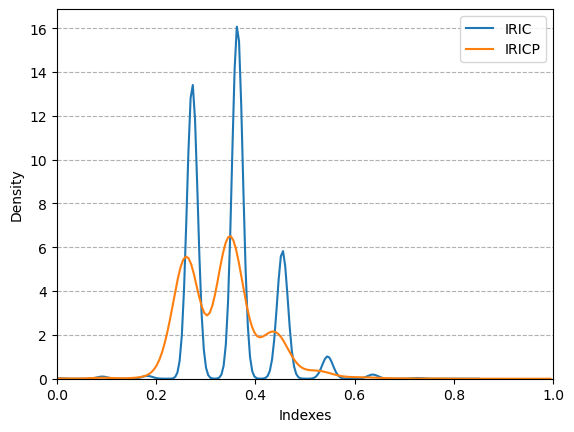

In [269]:
sns.kdeplot(data=secop2_CE_api, x='iric')
sns.kdeplot(data=secop2_CE_api, x='iricp', bw_adjust=2)
plt.xlabel('Indexes')
plt.legend(['IRIC', 'IRICP'])
plt.grid(axis='y', linestyle='--')
plt.xlim([0, 1])
plt.show()

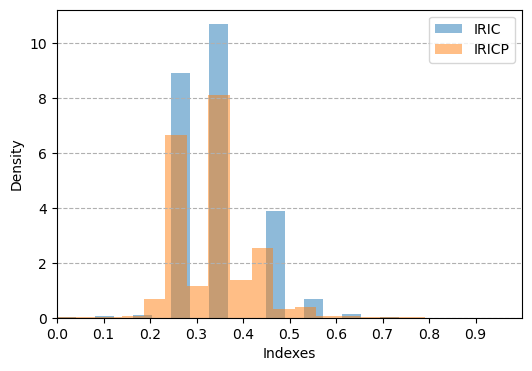

In [270]:
plt.figure(figsize=(6, 4))
plt.hist(secop2_CE_api['iric'], bins=20, alpha=0.5, density=True, label='IRIC')
plt.hist(secop2_CE_api['iricp'], bins=20, alpha=0.5, density=True, label='IRICP')
plt.xlabel('Indexes')
plt.ylabel('Density')
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1, step=0.1))
plt.grid(axis='y', linestyle='--')
plt.legend()
#plt.savefig('created_data/figures/hist_iric_iricp.svg')

In [271]:
print('Highest IRIC')
secop2_CE_api.sort_values('iric', ascending=False).head(1)

Highest IRIC


,id_contrato,nombre_entidad,Nit Entidad,sector,Entidad Centralizada,tipo_de_contrato,modalidad_de_contratacion,justificacion_modalidad_de,fecha_de_firma,tipodocproveedor,documento_proveedor,Es Grupo,Es Pyme,Habilita Pago Adelantado,Liquidación,Obligación Ambiental,valor_del_contrato,Saldo CDP,EsPostConflicto,Destino Gasto,Proveedores Invitados,Proveedores con Invitacion Directa,Conteo de Respuestas a Ofertas,proveedores_unicos_con,fecha_de_publicacion_del,fecha_de_ultima_publicaci,Numero_de_procesos_reportados,Codigo Segmento Categoria Principal,Numero multas SIC proveedor,Valor acumulado multas SIC proveedor,Tipo Empresa Proveedor,Dias Inicio-Firma Contrato,Dias Fin-Inicio Contrato,Dias Inicio-Firma Ejecucion,Dias Fin-Inicio Ejecucion,Dias Proveedor Inscrito,Mes Firma Contrato,Proporcion pagada adelantado,Saldo CDP respecto Valor,Grupo categoria principal,Tipo Empresa Proveedor Resumido,tiene_variables_portafolio,Dias Proceso Contratacion Abierto,Mes de Publicacion del Proceso,Tuvo_adiciones_valor,Tuvo_adiciones_tiempo,Tuvo_adiciones,Periodo de Decision,numero_adiciones_valor,numero_adiciones_tiempo,numero_procesos,segmentos_de_categoria_principal,codigos_entidades,tipo_documento,adicion_valor_proveedor,adicion_tiempo_proveedor,proveedor_recurrente,proveedor_multiproposito,contratacion_directa,contratacion_regimen_especial,ausencia_proceso_contratacion,duracion_extrema_proceso,periodo_decision_extremo,proponente_unico,presencia_errores,tipo_prestacion_servicios,iric,iricp
18474,CO1.PCCNTR.1525919,SECRETARIA DISTRITAL DEL HABITAT,899999061,"Vivienda, Ciudad y Territorio",Centralizada,Prestación de servicios,Contratación directa,serviciosprofesionales,2020-04-24,NIT,900062917,No,No,No,No,No,439105302,450794565.000,No,Funcionamiento,0.000,0.000,0.000,0.000,2020-04-25,2020-04-24,1.000,78000000,58,3564748930.000,No Definido,1,88,1,88,0,Abr,0.000,1.027,Servicios(No Admin),No Definido,1,0,Abr,0,0,0,0,7.000,10.000,35.000,3.000,14.000,NIT,1.000,1.000,1.000,1.000,1,0,0,1,1,1,1,1,0.818,0.930


In [272]:
print('Highest IRICP')
secop2_CE_api.sort_values('iricp', ascending=False).head(1)

Highest IRICP


,id_contrato,nombre_entidad,Nit Entidad,sector,Entidad Centralizada,tipo_de_contrato,modalidad_de_contratacion,justificacion_modalidad_de,fecha_de_firma,tipodocproveedor,documento_proveedor,Es Grupo,Es Pyme,Habilita Pago Adelantado,Liquidación,Obligación Ambiental,valor_del_contrato,Saldo CDP,EsPostConflicto,Destino Gasto,Proveedores Invitados,Proveedores con Invitacion Directa,Conteo de Respuestas a Ofertas,proveedores_unicos_con,fecha_de_publicacion_del,fecha_de_ultima_publicaci,Numero_de_procesos_reportados,Codigo Segmento Categoria Principal,Numero multas SIC proveedor,Valor acumulado multas SIC proveedor,Tipo Empresa Proveedor,Dias Inicio-Firma Contrato,Dias Fin-Inicio Contrato,Dias Inicio-Firma Ejecucion,Dias Fin-Inicio Ejecucion,Dias Proveedor Inscrito,Mes Firma Contrato,Proporcion pagada adelantado,Saldo CDP respecto Valor,Grupo categoria principal,Tipo Empresa Proveedor Resumido,tiene_variables_portafolio,Dias Proceso Contratacion Abierto,Mes de Publicacion del Proceso,Tuvo_adiciones_valor,Tuvo_adiciones_tiempo,Tuvo_adiciones,Periodo de Decision,numero_adiciones_valor,numero_adiciones_tiempo,numero_procesos,segmentos_de_categoria_principal,codigos_entidades,tipo_documento,adicion_valor_proveedor,adicion_tiempo_proveedor,proveedor_recurrente,proveedor_multiproposito,contratacion_directa,contratacion_regimen_especial,ausencia_proceso_contratacion,duracion_extrema_proceso,periodo_decision_extremo,proponente_unico,presencia_errores,tipo_prestacion_servicios,iric,iricp
18474,CO1.PCCNTR.1525919,SECRETARIA DISTRITAL DEL HABITAT,899999061,"Vivienda, Ciudad y Territorio",Centralizada,Prestación de servicios,Contratación directa,serviciosprofesionales,2020-04-24,NIT,900062917,No,No,No,No,No,439105302,450794565.000,No,Funcionamiento,0.000,0.000,0.000,0.000,2020-04-25,2020-04-24,1.000,78000000,58,3564748930.000,No Definido,1,88,1,88,0,Abr,0.000,1.027,Servicios(No Admin),No Definido,1,0,Abr,0,0,0,0,7.000,10.000,35.000,3.000,14.000,NIT,1.000,1.000,1.000,1.000,1,0,0,1,1,1,1,1,0.818,0.930


In [273]:
# Mean IRIC by entity
idx_ps = secop2_CE_api['tipo_prestacion_servicios'] == 1
entity_mean_idxs = secop2_CE_api.loc[~idx_ps, ['nombre_entidad', 'iric', 'iricp']].groupby('nombre_entidad').mean()

In [274]:
print('Entidades con mayor IRIC promedio')
entity_mean_idxs.sort_values('iric', ascending=False).head(5)

Entidades con mayor IRIC promedio


,iric,iricp
nombre_entidad,,
DEPARTAMENTO ADMINISTRATIVO DE LA DEFENSORIA DEL ESPACIO PUBLICO,0.636,0.768
ALCALDIA LOCAL DE CIUDAD BOLIVAR,0.636,0.743
TERMINAL DE TRANSPORTE S.A,0.636,0.681
ALCALDIA LOCAL DE MARTIRES,0.545,0.609
SECRETARÍA GENERAL DE LA ALCALDÍA MAYOR DE BOGOTÁ,0.466,0.441


In [275]:
print(entity_mean_idxs.sort_values('iric', ascending=False).head(5).to_latex())

\begin{tabular}{lrr}
\toprule
{} &  iric &  iricp \\
nombre\_entidad                                                   &       &        \\
\midrule
DEPARTAMENTO ADMINISTRATIVO DE LA DEFENSORIA DEL ESPACIO PUBLICO & 0.636 &  0.768 \\
ALCALDIA LOCAL DE CIUDAD BOLIVAR                                 & 0.636 &  0.743 \\
TERMINAL DE TRANSPORTE S.A                                       & 0.636 &  0.681 \\
ALCALDIA LOCAL DE MARTIRES                                       & 0.545 &  0.609 \\
SECRETARÍA GENERAL DE LA ALCALDÍA MAYOR DE BOGOTÁ                & 0.466 &  0.441 \\
\bottomrule
\end{tabular}



### Comparación con probabilidad de adiciones en valor

Las variables para adiciones en valor: 
```python
        ['Valor del Contrato', 'Dias Inicio-Firma Contrato',
       'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
       'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito',
       'Sector_Cultura']
```

Las variables para adiciones en tiempo: 
```python
        ['Valor del Contrato', 'Dias Inicio-Firma Contrato',
       'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
       'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito']
```

In [281]:
secop2_CE_api['Sector_Cultura'] = (secop2_CE_api['sector'] == 'Cultura')*1

In [290]:
# Cargar modelo adiciones en valor
filename_model = 'created_data/trained_models/model_secopII_AdValor_TipoContratoTodos_rf.pkl'
filename_scaler = 'created_data/trained_models/scaler_secopII_AdValor_TipoContratoTodos_rf.pkl'
forest_overruns = joblib.load(filename_model)
scaler_overruns = joblib.load(filename_scaler)

predict_vars = ['valor_del_contrato', 'Dias Inicio-Firma Contrato',
                'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
                'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito',
                'Sector_Cultura']
X_overruns = scaler_overruns.transform(secop2_CE_api[predict_vars])
y_pred = forest_overruns.predict_proba(X_overruns)
secop2_CE_api['overrun_prob'] = y_pred[:, 1]

In [291]:
# Cargar modelo adiciones en tiempo
filename_model = 'created_data/trained_models/model_secopII_AdTiempo_TipoContratoTodos_rf.pkl'
filename_scaler = 'created_data/trained_models/scaler_secopII_AdTiempo_TipoContratoTodos_rf.pkl'
forest_delays = joblib.load(filename_model)
scaler_delays = joblib.load(filename_scaler)

predict_vars = ['valor_del_contrato', 'Dias Inicio-Firma Contrato',
                'Dias Fin-Inicio Contrato', 'Dias Inicio-Firma Ejecucion',
                'Dias Fin-Inicio Ejecucion', 'Dias Proveedor Inscrito']
X_delays = scaler_delays.transform(secop2_CE_api[predict_vars])
y_pred = forest_delays.predict_proba(X_delays)
secop2_CE_api['delays_prob'] = y_pred[:, 1]

In [293]:
secop2_CE_api[['overrun_prob', 'delays_prob']].describe()

,overrun_prob,delays_prob
count,18796.000,18796.000
mean,0.182,0.455
std,0.218,0.383
min,0.000,0.000
25%,0.030,0.080
50%,0.100,0.350
75%,0.240,0.890
max,1.000,1.000


In [294]:
secop2_CE_api[['overrun_prob', 'delays_prob', 'iric', 'iricp']].corr()

,overrun_prob,delays_prob,iric,iricp
overrun_prob,1.000,-0.006,-0.006,0.043
delays_prob,-0.006,1.000,0.019,0.068
iric,-0.006,0.019,1.000,0.969
iricp,0.043,0.068,0.969,1.000


In [296]:
import seaborn as sns

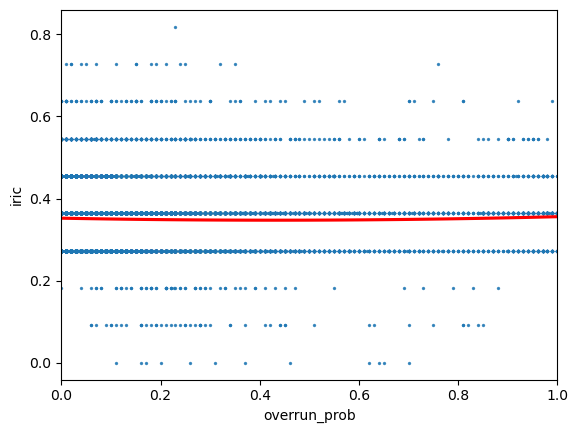

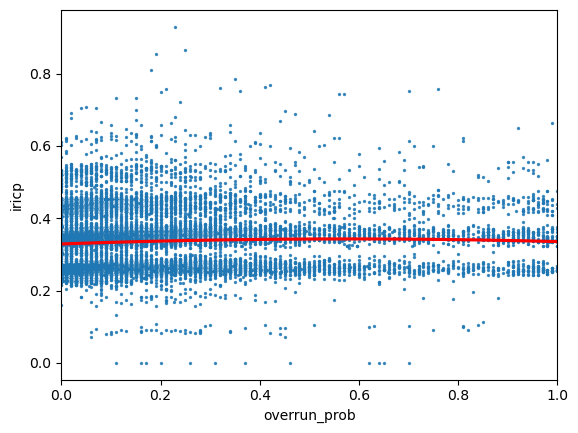

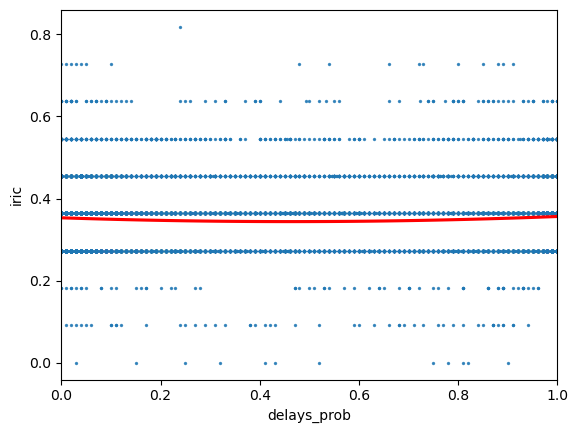

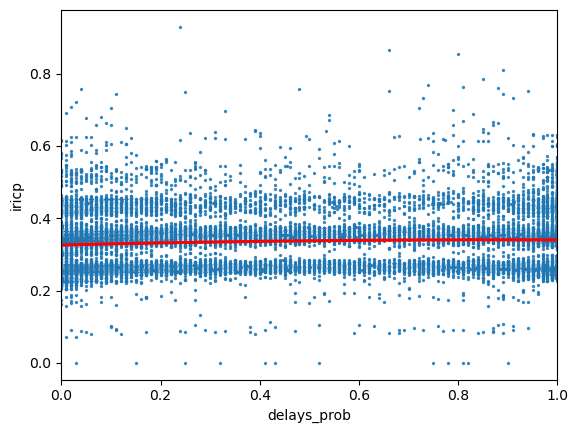

In [302]:
for prob in ['overrun_prob', 'delays_prob']:
    for inds in ['iric', 'iricp']:
        plt.figure()
        sns.regplot(data=secop2_CE_api, x=prob, y=inds, 
                    order=2, ci=None, scatter_kws={'s':2}, line_kws=dict(color="r"))
        plt.show()